In [ ]:
# Injection and Recovery

In [1]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 
# Read in the data from the fits file 
from test_analysis import read_in_fits

## Normalize the sky 
- assign each readout median to correspond to 9.088e05 ph/pixel. 

In [5]:
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')

Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1


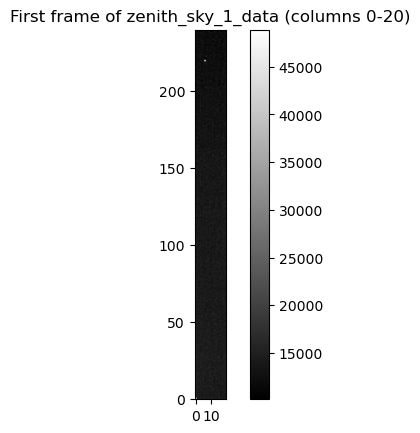

In [9]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what a channel looks like
plt.imshow(zenith_sky_1_data[0, :, :20], cmap='gray', origin='lower')
plt.title("First frame of zenith_sky_1_data (columns 0-20)")
plt.colorbar()
plt.show()

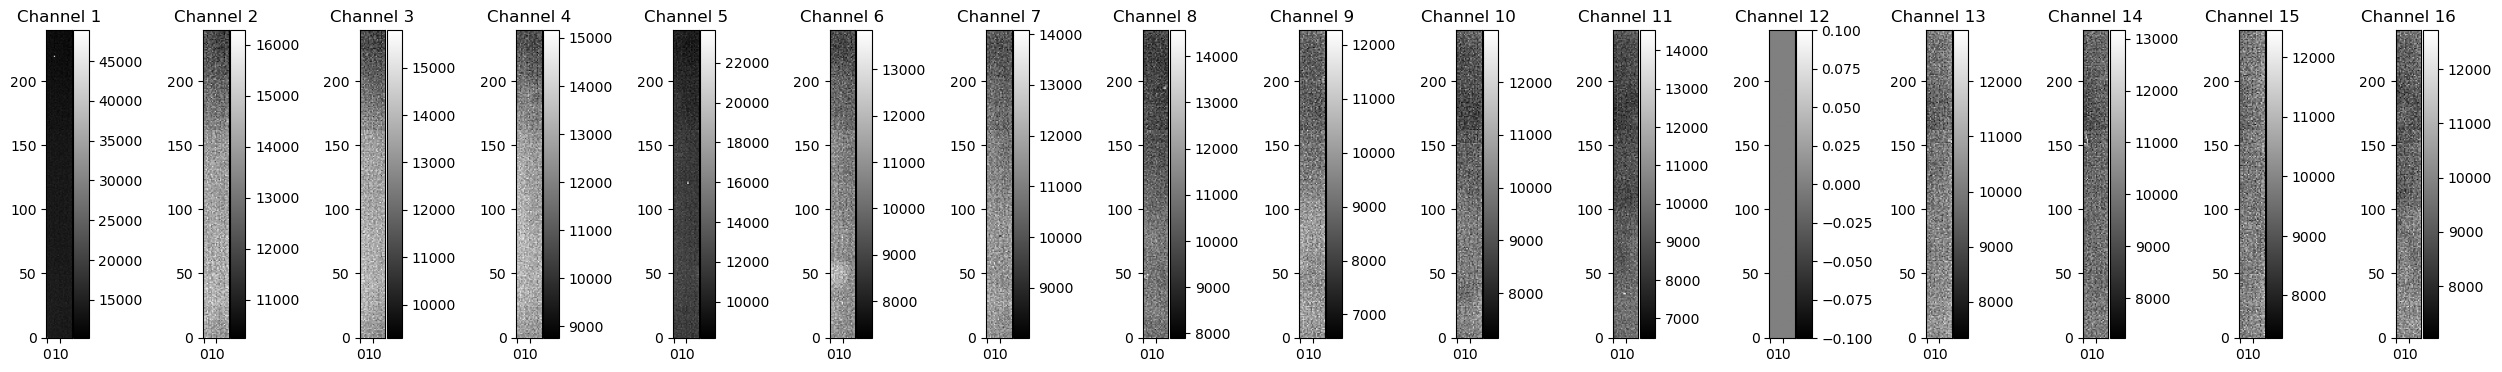

In [15]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(zenith_sky_1_data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

clearly channel 12 has something wrong with it. maybe what we can do is take the median of each and normalize the values to the "empirical sky rate".   

/tmp/ipykernel_192106/164220779.py:4: RuntimeWarning: invalid value encountered in divide
  channel_data[i] = channel_data[i] / np.median(channel_data[i])


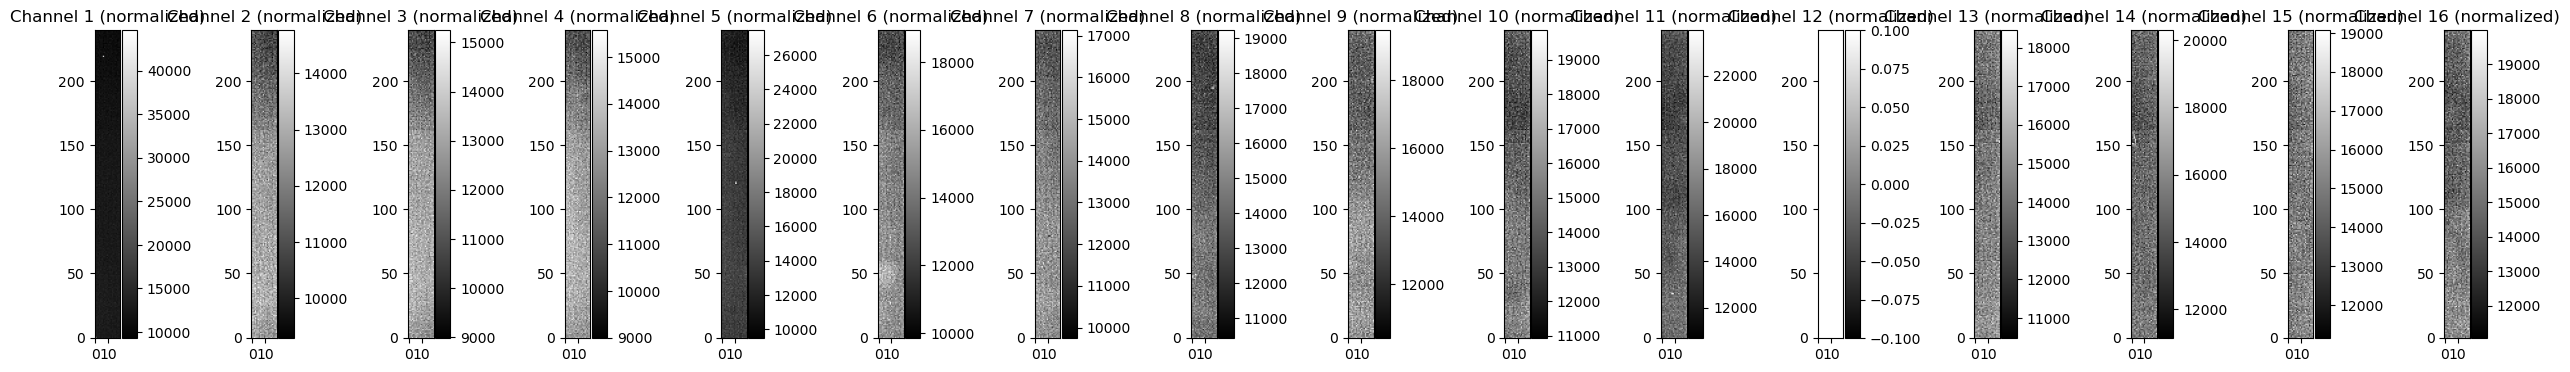

In [21]:
fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))
for i in range(num_channels):
    # divide each pixel by the median of the entire channel to normalize
    channel_data[i] = channel_data[i] / np.median(channel_data[i])
    # Multiply by the actual sky rate of 9.088e5 counts to get a sky rate in counts per exposure
    channel_data[i] = channel_data[i] * 9087.657082019272
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {} (normalized)".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)
plt.show()



In [16]:
target_median = 9.088e5
num_channels = 16
channel_width = 20

# copy so original stays unchanged
zenith_sky_1_data_norm = zenith_sky_1_data.astype(float).copy()

channel_medians = []
scale_factors = []

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width

    channel = zenith_sky_1_data_norm[:, :, c0:c1]
    med = np.nanmedian(channel)
    scale = target_median / med if med != 0 else np.nan

    zenith_sky_1_data_norm[:, :, c0:c1] = channel * scale

    channel_medians.append(med)
    scale_factors.append(scale)

print("Original channel medians:", np.array(channel_medians))
print("Scale factors:", np.array(scale_factors))
print("New channel medians:",
      np.array([np.nanmedian(zenith_sky_1_data_norm[:, :, i*channel_width:(i+1)*channel_width])
                for i in range(num_channels)]))

Original channel medians: [ 9947. 10023.  9408.  8848.  7823.  6643.  7468.  6883.  5726.  5943.
  5510.     0.  6367.  5895.  5936.  5782.]
Scale factors: [ 91.36423042  90.67145565  96.59863946 102.7124774  116.17026716
 136.80566009 121.6925549  132.03544966 158.714635   152.91940098
 164.93647913          nan 142.73598241 154.16454623 153.09973046
 157.17744725]


/tmp/ipykernel_192106/4093442303.py:27: RuntimeWarning: All-NaN slice encountered
  np.array([np.nanmedian(zenith_sky_1_data_norm[:, :, i*channel_width:(i+1)*channel_width])


New channel medians: [908800. 908800. 908800. 908800. 908800. 908800. 908800. 908800. 908800.
 908800. 908800.     nan 908800. 908800. 908800. 908800.]


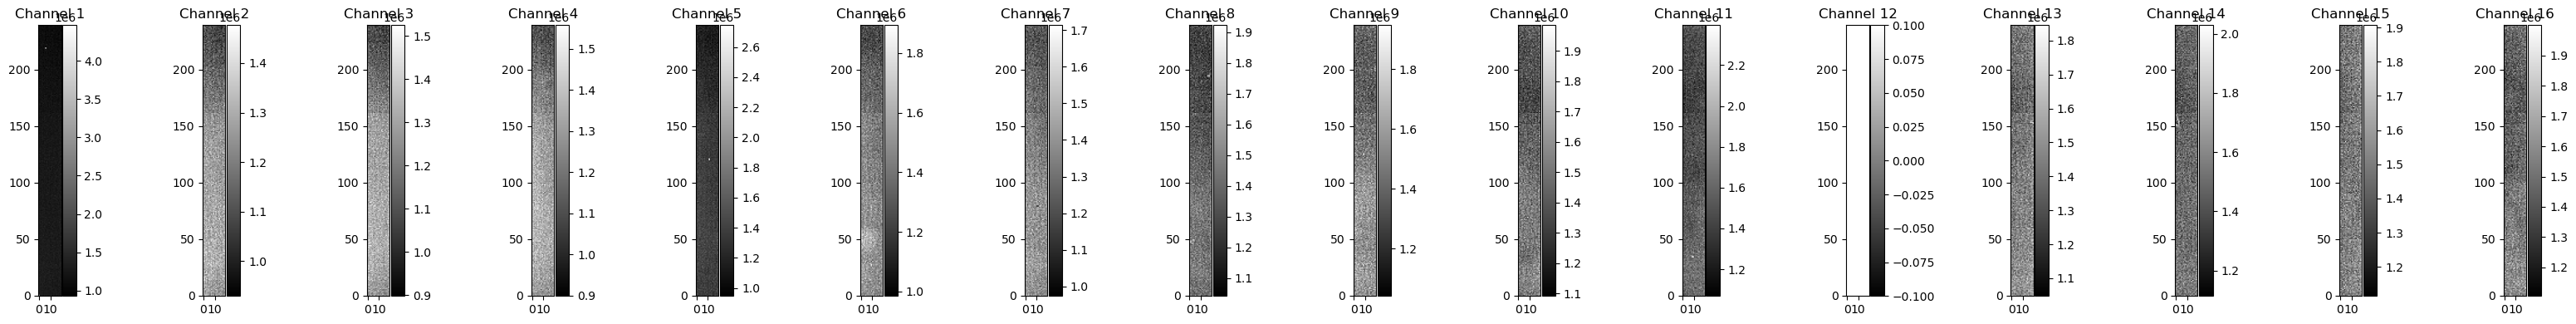

In [18]:
num_channels = 16
channel_width = 20

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    c0 = i * channel_width
    c1 = (i + 1) * channel_width
    
    # first frame of normalized data for this channel
    ch0 = zenith_sky_1_data_norm[0, :, c0:c1]
    
    im = axes[i].imshow(ch0, cmap='gray', origin='lower')
    axes[i].set_title(f"Channel {i+1}")
    plt.colorbar(im, ax=axes[i], pad=0.01)

plt.tight_layout()
plt.show()

In [20]:
target_median = 9.088e5
num_columns = zenith_sky_1_data.shape[2]  # total number of columns

# copy so original stays unchanged
zenith_sky_1_data_norm = zenith_sky_1_data.astype(float).copy()

column_medians = []
scale_factors = []

for col in range(num_columns):
    column_data = zenith_sky_1_data_norm[:, :, col]
    med = np.nanmedian(column_data)
    scale = target_median / med if med != 0 else np.nan
    
    zenith_sky_1_data_norm[:, :, col] = column_data * scale
    
    column_medians.append(med)
    scale_factors.append(scale)

print(f"Normalized {num_columns} columns")
print(f"Original median range: {np.min(column_medians):.2e} to {np.max(column_medians):.2e}")
print(f"Scale factor range: {np.min(scale_factors):.2f} to {np.max(scale_factors):.2f}")
print(f"New overall median: {np.nanmedian(zenith_sky_1_data_norm):.2e}")

Normalized 320 columns
Original median range: 0.00e+00 to 1.05e+04
Scale factor range: nan to nan
New overall median: 9.09e+05
